# Basic tracking of the LCLS cu_hxr design model

In [1]:
from pytao import Tao
from pmd_beamphysics import ParticleGroup
from scipy.constants import c
import matplotlib.pyplot as plt
import numpy as np
%config InlineBackend.figure_format = 'retina'

# Setup

In [2]:
BEAMPATH = 'cu_hxr'

# Initialize Tao

In [3]:
tao = Tao(f'-init $LCLS_LATTICE/bmad/models/{BEAMPATH}/tao.init -slice BEGINNING:BEGUNDH -noplot')

In [4]:
# Explicitly save beam 
tao.cmd('set beam saved_at = MARKER::*')
#tao.cmd('set beam saved_at = BEGUNDH,ENDUNDH') 

[]

In [5]:
# Set the comb spacing 
tao.cmd('set beam comb_ds_save = 0.1') # 10 cm 

[]

In [6]:
# Turn on CSR
tao.cmd(f'call $LCLS_LATTICE/bmad/models/{BEAMPATH}/scripts/Activate_CSR.tao');

In [7]:
# Set the number of particles
tao.cmd('set beam_init n_particle = 10000')

[]

# Run the beam

In [8]:
%%time
tao.cmd('set global track_type = beam;set global track_type = single')

CPU times: user 4min 21s, sys: 4.15 s, total: 4min 25s
Wall time: 2min 4s


['',
 'Tao: set global track_type = beam',
 'Beam at Element: 1671. Time: 1 min',
 'Beam at Element: 1886. Time: 2 min',
 '',
 'Tao: set global track_type = single']

# Analyze output

In [9]:
def get_beam(ele_id):
    """
    Return a ParticleGroup at a particlular element
    with only the live particles
    """
    P = ParticleGroup(data=tao.bunch_data(ele_id))
    # Select out live particles
    P = P[P.status==1]    
    
    return P

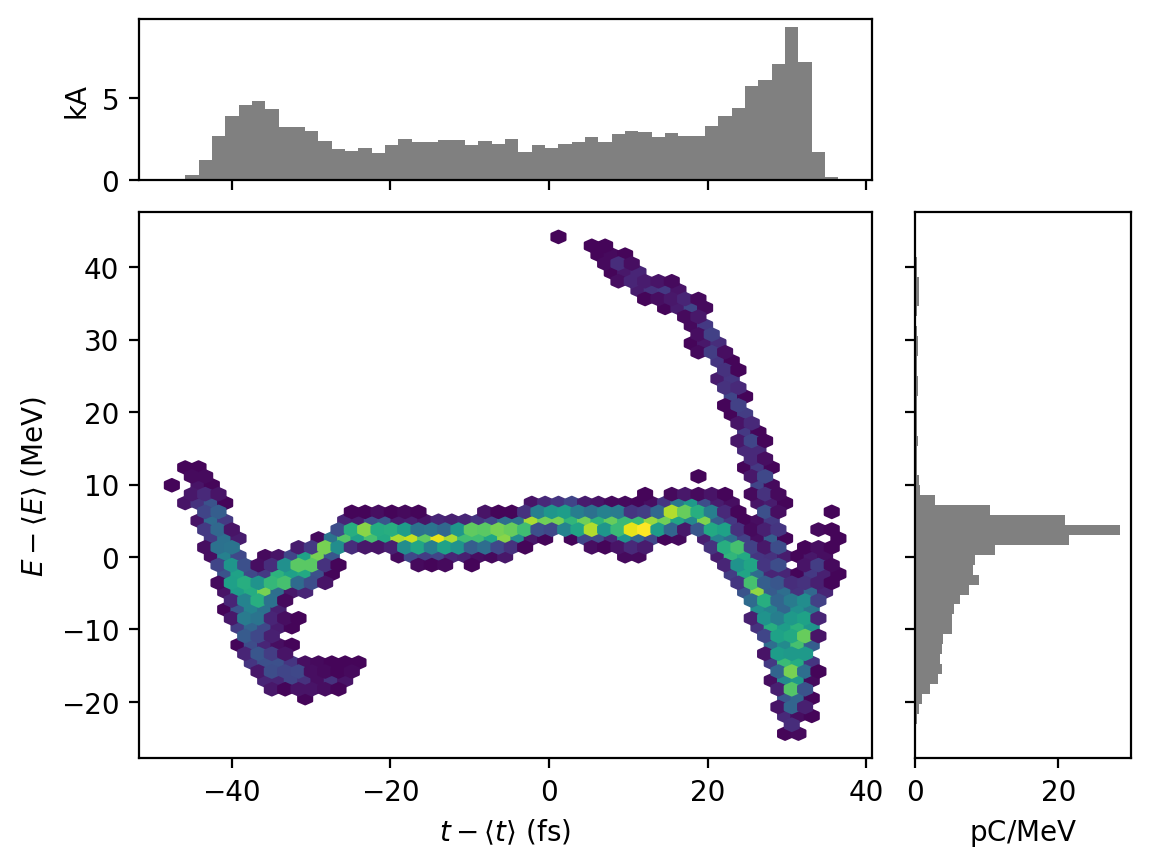

In [10]:
P1 = get_beam('BEGUNDH')
P1.plot('delta_t', 'delta_energy')

# Bunch comb plot


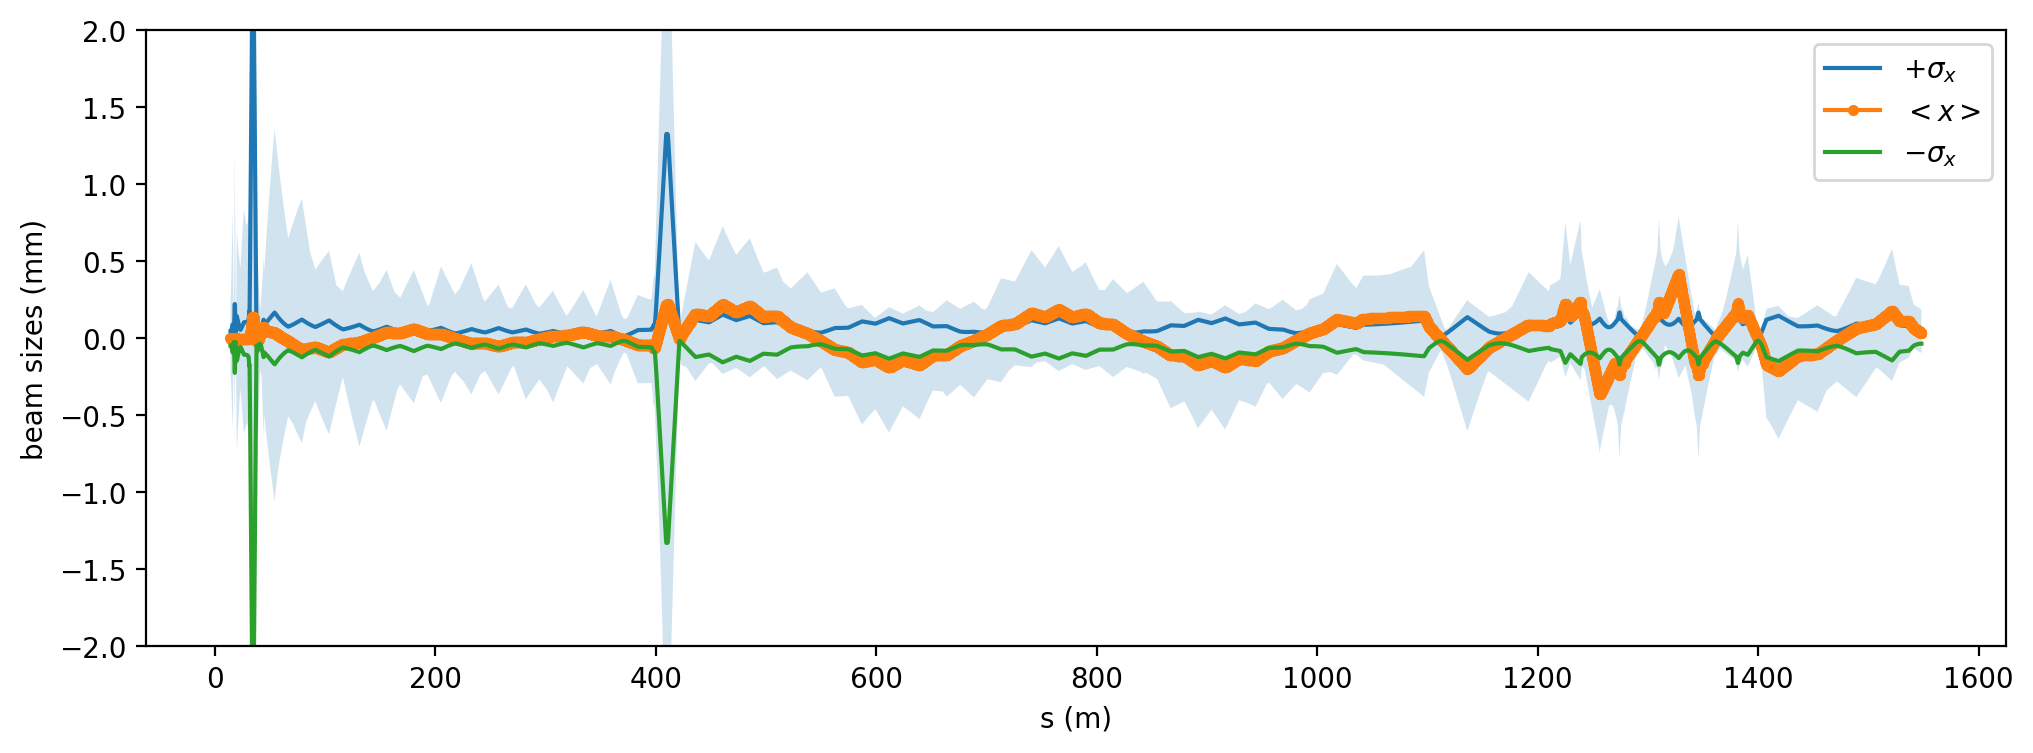

In [11]:
s = tao.bunch_comb('s')
mean_x = tao.bunch_comb('x')
max_x = mean_x + tao.bunch_comb('rel_max.1')
min_x = mean_x + tao.bunch_comb('rel_min.1')
sigma_x = np.sqrt(tao.bunch_comb('sigma.11'))


fig, ax = plt.subplots(figsize=(12,4))

yscale = 1e3 # m->mm
ax.fill_between(s, min_x*yscale, max_x*yscale, alpha=0.2)
ax.plot(s, sigma_x*yscale, label=r'$+\sigma_x$')
ax.plot(s, mean_x*yscale, label=r'$<x>$', marker='.')
ax.plot(s, -sigma_x*yscale, label=r'$-\sigma_x$')
ax.set_xlabel('s (m)')
ax.set_ylabel('beam sizes (mm)')

ax.set_ylim(-2, 2)
plt.legend()


Text(0.5, 0, '$s$ (m)')

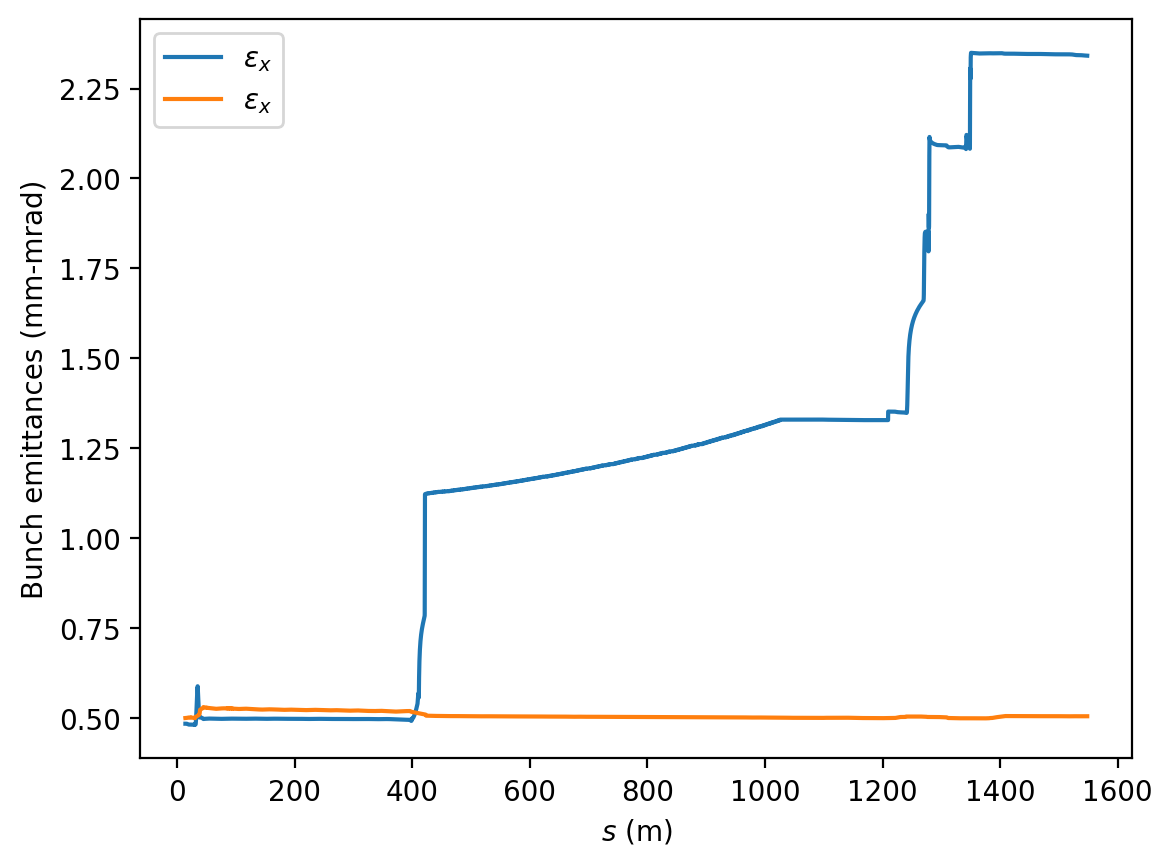

In [12]:
s = tao.bunch_comb('s')
fig, ax = plt.subplots()
ax.plot(s, 1e6*tao.bunch_comb('x.norm_emit'), label=r'$\epsilon_x$')
ax.plot(s, 1e6*tao.bunch_comb('y.norm_emit'), label=r'$\epsilon_x$')
plt.legend()
ax.set_ylabel('Bunch emittances (mm-mrad)')
ax.set_xlabel(r'$s$ (m)')

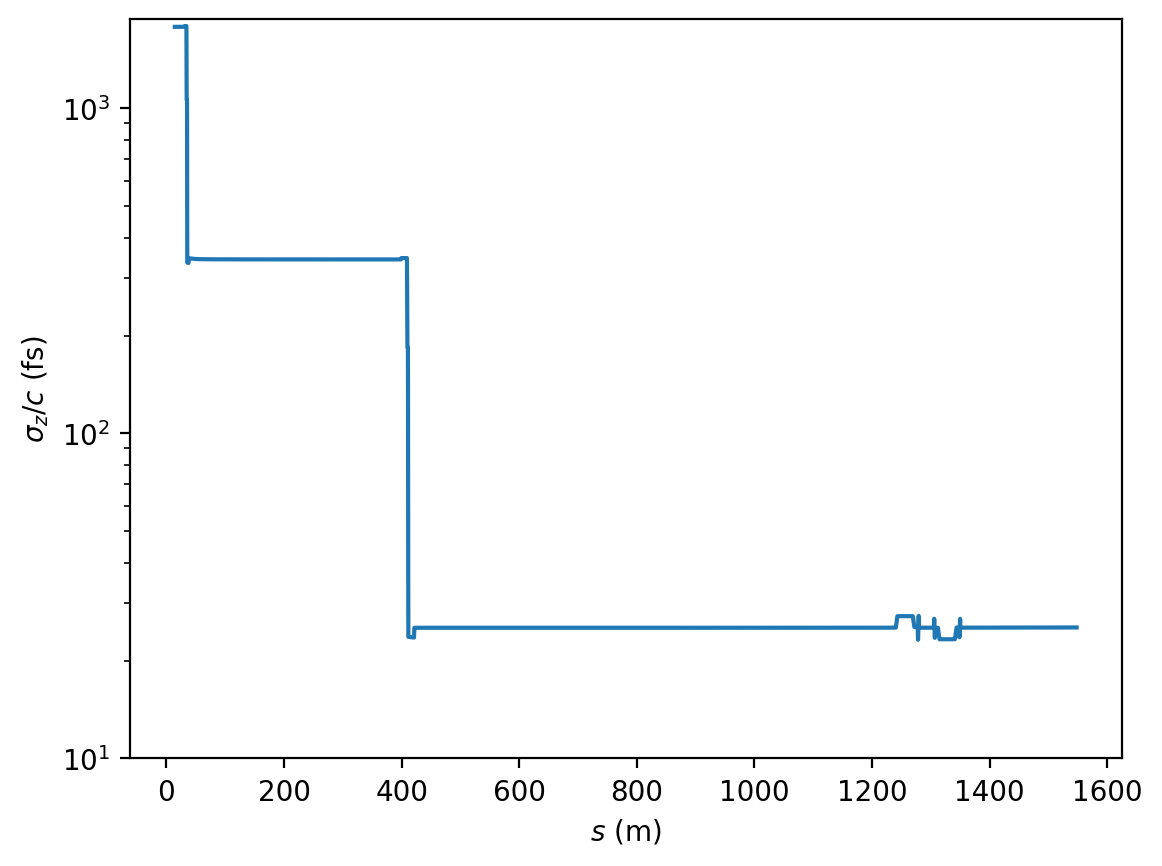

In [13]:


s = tao.bunch_comb('s')
sigma_z =  tao.bunch_comb('z.sigma')
fig, ax = plt.subplots()
ax.plot(s,sigma_z/c*1e15)
ax.set_ylabel(r'$\sigma_z/c$ (fs)')
ax.set_xlabel(r'$s$ (m)')
ax.set_ylim(10, None)
ax.set_yscale('log')
#ax2 = ax.twinx()
#ax2.plot(s, sigma_z, color='red')
#ax2.set_yscale('log')